# Experiments with one-branch models: with rasterio

In [1]:
#check the evironement path
import sys
sys.executable

'/usr/bin/python'

In [2]:
import tensorflow as tf
print(tf.__version__)
import keras
print(keras.__version__)

from keras import backend as K

1.15.2
2.2.4


Using TensorFlow backend.


# Loading Data: Training images + labels

In [3]:
import os
from glob import glob
import numpy as np
import rasterio

import random
from random import randint
random.seed(1337)
np.random.seed(1337)
#tf.set_random_seed(1337)

from keras.utils import to_categorical

In [4]:
path_data="/linux_data/test_S1TS_S2/*/"
data = glob(path_data)


data_tiles_list = []
label_tiles_list = []


data_tiles_list.append(glob(data[1]+ "/*.tif"))
label_tiles_list.append(glob(data[0]+ "/*.tif"))


data_tiles_list = [y for x in data_tiles_list for y in x]
label_tiles_list = [y for x in label_tiles_list for y in x]
print(len(data_tiles_list))
print(len(label_tiles_list))

4518
4518


### Training images

#### Data set with 10-band images

In [5]:
#nb_tiles=int(len(data_tiles_list)*0.8)
nb_tiles=10
tr_images = []
for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    data_in = rasterio.open(data_tiles_list[i]) #opens the .tif/Raster in an array
    
    t = np.expand_dims(data_in.read(1), axis=2) #expands the array by 1 dimension
    for j in range(2,11): #expands the array by j dimensions and adds them together (concatenate)
        t = np.concatenate((t, np.expand_dims(data_in.read(j), axis=2)), axis=2)
    tr_images.append(t)    

training_images = np.asarray(tr_images) # converts list training_images into an array
del tr_images
print(training_images.shape)

#Calculate mean and std for all data set corresponding to each channel
channels=training_images.shape[3]
mean=[]
std=[]
for i in range(channels):
    mean.append(np.mean(training_images[:,:,:,i]))
    std.append(np.std(training_images[:,:,:,i]))

0/10
1/10
2/10
3/10
4/10
5/10
6/10
7/10
8/10
9/10
(10, 256, 256, 10)


#### Data set with 34-band images

In [ ]:
nb_tiles=10
#nb_tiles=int(len(data_tiles_list)*0.8)
tr_images = []

for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    data_in = rasterio.open(data_tiles_list[i]) #opens the .tif/Raster in an array
    
    t = np.expand_dims(data_in.read(1), axis=2) #expands the array by 1 dimension
    for j in range(2,35): #expands the array by j dimensions and adds them together (concatenate)
        t = np.concatenate((t, np.expand_dims(data_in.read(j), axis=2)), axis=2)
    tr_images.append(t)    

training_images = np.asarray(tr_images) # converts list training_images into an array
del tr_images
print(training_images.shape)

#Calculate mean and std for all data set corresponding to each channel
channels=training_images.shape[3]
mean=[]
std=[]
for i in range(channels):
    mean.append(np.mean(training_images[:,:,:,i]))
    std.append(np.std(training_images[:,:,:,i]))

#### Data set with 24-band images

In [ ]:
nb_tiles=10
#nb_tiles=int(len(data_tiles_list)*0.8)

tr_images = []
for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    data_in = rasterio.open(data_tiles_list[i]) #opens the .tif/Raster in an array
    
    t = np.expand_dims(data_in.read(11), axis=2) #expands the array by 1 dimension
    for j in range(12,35): #expands the array by j dimensions and adds them together (concatenate)
        t = np.concatenate((t, np.expand_dims(data_in.read(j), axis=2)), axis=2)
    tr_images.append(t)    

training_images = np.asarray(tr_images) # converts list training_images into an array
del tr_images
print(training_images.shape)

#Calculate mean and std for all data set corresponding to each channel
channels=training_images.shape[3]
mean=[]
std=[]
for i in range(channels):
    mean.append(np.mean(training_images[:,:,:,i]))
    std.append(np.std(training_images[:,:,:,i]))

### Data Normalization

In [7]:
images_norm=training_images-mean
images_norm/=std

print(images_norm.shape)

(10, 256, 256, 10)


### Labels

In [ ]:
# Labels for training
from keras.utils import to_categorical

tr_labels=[]
for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    data_in = rasterio.open(label_tiles_list[i]) #opens the .tif/Raster in an array    
    tr_labels.append(data_in.read(1))
        
training_labels = np.asarray(tr_labels) # converts list training_images into an array
del tr_labels
training_labels = np.expand_dims(training_labels, axis=3)

#Multiclass labels
training_labels=to_categorical(training_labels)

print(training_labels.shape)

#### Labels for training + calculation of pixel percentage per classes

In [6]:
nb_labels = 18 #should be known in prior
tr_labels=[]
weight=[]

for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    weightspers=[]
    data_in = rasterio.open(label_tiles_list[i]) #opens the .tif/Raster in an array    
    tr_labels.append(data_in.read(1))
    for j in range(nb_labels):
        weightspers.append(np.sum(data_in.read(1)==j))
    weight.append(weightspers)
    
training_labels = np.asarray(tr_labels) # converts list training_images into an array
del tr_labels
training_labels = np.expand_dims(training_labels, axis=3)

#weights=np.sum(weight,axis=0)/(nb_tiles*nb_rows*nb_cols) #percentage of classes

#Multiclass labels
training_labels=to_categorical(training_labels)

print(training_labels.shape)

0/10
1/10
2/10
3/10
4/10
5/10
6/10
7/10
8/10
9/10
(10, 256, 256, 18)


### Data augmentation

In [8]:
rotation = [1]
flip_horizontal = True

print("Number of training labels/images: " + str(training_labels.shape))

Number of training labels/images: (10, 256, 256, 18)


In [9]:
####Rotation
for i in rotation:
    images_norm = np.concatenate((images_norm, np.rot90(images_norm[0:2000], i, (1,2))), axis=0)
    training_labels = np.concatenate((training_labels, np.rot90(training_labels[0:2000], i, (1,2))), axis=0)
print("After rotation:")
print("Number of training labels/images: " + str(training_labels.shape))

After rotation:
Number of training labels/images: (20, 256, 256, 18)


In [10]:
#######Horizontal flip   
if flip_horizontal:
    images_norm = np.concatenate((images_norm, np.flip(images_norm[2001:4001], 2)), axis=0)
    training_labels = np.concatenate((training_labels, np.flip(training_labels[2001:4001], 2)), axis=0)
    print("After horizontal flip:")
    print("Number of training labels/images: " + str(training_labels.shape))

After horizontal flip:
Number of training labels/images: (20, 256, 256, 18)


### Settings of data set parameters

In [11]:
nb_labels = training_labels.shape[3]
print(nb_labels)

# The dimensions of the input images
nb_rows = training_images.shape[1]
print(nb_rows)
nb_cols = training_images.shape[2]
print(nb_cols)
channels= training_images.shape[3]
print(channels)

if K.image_data_format() == 'channels_first':
    channel_axis = 1
    input_shape = (nb_rows, nb_cols, channels)
if K.image_data_format() == 'channels_last':
    channel_axis = 3
    input_shape = (nb_rows, nb_cols, channels)

print(input_shape)

18
256
256
10
(256, 256, 10)


# Model Definition

In [12]:
from keras.layers import Input
from keras.models import Model
#from keras import backend as K
from keras import layers

#######
from keras.layers import BatchNormalization
from keras.layers import Conv2D
from keras.layers import Activation
from keras.layers import Lambda,Add,Reshape
from keras.layers import MaxPooling2D,Dropout


#######
from keras.layers import AlphaDropout
from keras.layers import concatenate
from keras.layers import Conv2DTranspose
from keras.layers import ConvLSTM2D
##
from keras.layers import AtrousConvolution2D

### Elementary blocks

In [13]:
def identity_block(input_tensor, kernel_size, filters, stage, block):
    """The identity block is the block that has no conv layer at shortcut.
    # Arguments
        input_tensor: input tensor
        kernel_size: defualt 3, the kernel size of middle conv layer at main path
        filters: list of integers, the filterss of 3 conv layer at main path
        stage: integer, current stage label, used for generating layer names
        block: 'a','b'..., current block label, used for generating layer names
    # Returns
        Output tensor for the block.
    """
    filters1, filters2, filters3 = filters
    if K.image_data_format() == 'channels_last':
        bn_axis = 3
    else:
        bn_axis = 1
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'
    act_name = 'act' + str(stage) + block

    x = Conv2D(filters1, (1, 1), name=conv_name_base + '2a')(input_tensor)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + '2a')(x)
    x = Activation('relu')(x)

    x = Conv2D(
        filters2, kernel_size, padding='same', name=conv_name_base + '2b')(x)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + '2b')(x)
    x = Activation('relu')(x)

    x = Conv2D(filters3, (1, 1), name=conv_name_base + '2c')(x)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + '2c')(x)

    x = layers.add([x, input_tensor])
    x = Activation('relu', name=act_name)(x)
    return x


def conv_block(input_tensor,
               kernel_size,
               filters,
               stage,
               block,
               strides=(2, 2)):
    """conv_block is the block that has a conv layer at shortcut
    # Arguments
        input_tensor: input tensor
        kernel_size: defualt 3, the kernel size of middle conv layer at main path
        filters: list of integers, the filterss of 3 conv layer at main path
        stage: integer, current stage label, used for generating layer names
        block: 'a','b'..., current block label, used for generating layer names
    # Returns
        Output tensor for the block.
    Note that from stage 3, the first conv layer at main path is with strides=(2,2)
    And the shortcut should have strides=(2,2) as well
    """
    filters1, filters2, filters3 = filters
    if K.image_data_format() == 'channels_last':
        bn_axis = 3
    else:
        bn_axis = 1
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'
    act_name = 'act' + str(stage) + block

    x = Conv2D(
        filters1, (1, 1), strides=strides,
        name=conv_name_base + '2a')(input_tensor)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + '2a')(x)
    x = Activation('relu')(x)

    x = Conv2D(
        filters2, kernel_size, padding='same', name=conv_name_base + '2b')(x)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + '2b')(x)
    x = Activation('relu')(x)

    x = Conv2D(filters3, (1, 1), name=conv_name_base + '2c')(x)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + '2c')(x)

    shortcut = Conv2D(
        filters3, (1, 1), strides=strides,
        name=conv_name_base + '1')(input_tensor)
    shortcut = BatchNormalization(
        axis=bn_axis, name=bn_name_base + '1')(shortcut)

    x = layers.add([x, shortcut])
    x = Activation('relu', name=act_name)(x)
    return x

In [14]:
def conv_block_atrous(input_tensor, kernel_size, filters, stage, block, atrous_rate=(2, 2)):
    """conv_block is the block that has a conv layer at shortcut deploying the atrous conv.
    # Arguments
        input_tensor: input tensor
        kernel_size: defualt 3, the kernel size of middle conv layer at main path
        filters: list of integers, the filterss of 3 conv layer at main path
        stage: integer, current stage label, used for generating layer names
        block: 'a','b'..., current block label, used for generating layer names
        atrous_rate: the dilation rate for the atrous conv
    # Returns
        Output tensor for the block.
    Note that from stage 3, the first conv layer at main path is with strides=(2,2)
    And the shortcut should have strides=(2,2) as well
    """
    nb_filter1, nb_filter2, nb_filter3 = filters
    bn_axis = 1

    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'

    x = Conv2D(nb_filter1, 1, 1, name=conv_name_base + '2a')(input_tensor)
    x = BatchNormalization(name=bn_name_base + '2a')(x)
    x = Activation('relu')(x)

    x = AtrousConvolution2D(nb_filter2, kernel_size, kernel_size, border_mode='same',
                            atrous_rate=atrous_rate, name=conv_name_base + '2b')(x)
    x = BatchNormalization(name=bn_name_base + '2b')(x)
    x = Activation('relu')(x)

    x = Conv2D(nb_filter3, 1, 1, name=conv_name_base + '2c')(x)
    x = BatchNormalization(name=bn_name_base + '2c')(x)

    shortcut = Conv2D(nb_filter3, 1, 1, name=conv_name_base + '1')(input_tensor)
    shortcut = BatchNormalization(name=bn_name_base + '1')(shortcut)
    
    x = layers.add([x, shortcut])
    x = Activation('relu')(x)
    return x


def identity_block_atrous(input_tensor, kernel_size, filters, stage, block, atrous_rate=(2, 2)):
    """The identity atrous block is the block that has no conv layer at shortcut.
        It deploys the atrous conv in the direct path.
    # Arguments
        input_tensor: input tensor
        kernel_size: defualt 3, the kernel size of middle conv layer at main path
        filters: list of integers, the filterss of 3 conv layer at main path
        stage: integer, current stage label, used for generating layer names
        block: 'a','b'..., current block label, used for generating layer names
        atrous_rate: the dilation rate for the atrous conv
    # Returns
        Output tensor for the block.
    """
    nb_filter1, nb_filter2, nb_filter3 = filters
    bn_axis = 1

    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'

    x =Conv2D(nb_filter1, 1, 1, name=conv_name_base + '2a')(input_tensor)
    x = BatchNormalization(name=bn_name_base + '2a')(x)
    x = Activation('relu')(x)

    x = AtrousConvolution2D(nb_filter2, kernel_size, kernel_size, atrous_rate=atrous_rate,
                            border_mode='same', name=conv_name_base + '2b')(x)
    x = BatchNormalization(name=bn_name_base + '2b')(x)
    x = Activation('relu')(x)

    x = Conv2D(nb_filter3, 1, 1, name=conv_name_base + '2c')(x)
    x = BatchNormalization(name=bn_name_base + '2c')(x)

    x = layers.add([x, input_tensor])
    x = Activation('relu')(x)
    return x

## State-of-the-art architectures

### DeepLab with ResNet50 as backbone network

In [15]:
def Deeplab_ResNet50(input_shape=None):
    """The Definition of the Deeplab architecture with ResNet50 as backbone model
        
        # Arguments
        input_shape: the shape of the input tensor
        
        # Returns
        the model definition using keras
    """
    img_input = Input(shape=input_shape,name='Input')
    
    bn_axis = 3

    x = conv_block(img_input, 3, [64, 64, 256], stage=1, block='a', strides=(1, 1))
    x = Conv2D(64, 7, padding='same', name='conv1')(x)
    x = BatchNormalization(axis=bn_axis, name='bn_conv1')(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)


    x = conv_block(x, 3, [64, 64, 256], stage=2, block='a')
    x = identity_block(x, 3, [64, 64, 256], stage=2, block='b')
    x = identity_block(x, 3, [64, 64, 256], stage=2, block='c')
    
    x = conv_block(x, 3, [128,128,512], stage=3, block='a')
    x = identity_block(x, 3, [128,128,512], stage=3, block='b')
    x = identity_block(x, 3, [128,128,512], stage=3, block='c')
    x = identity_block(x, 3, [128,128,512], stage=3, block='d')


    x = conv_block_atrous(x, 3, [256, 256, 1024], stage=4, block='a')
    x = identity_block_atrous(x, 3, [256, 256, 1024], stage=4, block='b')
    x = identity_block_atrous(x, 3, [256, 256, 1024], stage=4, block='c')
    x = identity_block_atrous(x, 3, [256, 256, 1024], stage=4, block='d')
    x = identity_block_atrous(x, 3, [256, 256, 1024], stage=4, block='e')
    x = identity_block_atrous(x, 3, [256, 256, 1024], stage=4, block='f') #/16

    #x1 = AveragePooling2D((2, 2), name='avg_pool')(x1)
#-----------End Resnet50
    
    # branching for Atrous Spatial Pyramid Pooling
    # hole = 6
    b1 = conv_block_atrous(x, 3,[512, 512, 2048], stage=5, block='a',atrous_rate=(6, 6))
    b1 = identity_block_atrous(b1, 3, [512, 512, 2048], stage=5, block='b',atrous_rate=(6, 6))
    b1 = identity_block_atrous(b1, 3, [512, 512, 2048], stage=5, block='c',atrous_rate=(6, 6))
    b1 = Dropout(0.5)(b1)

    # hole = 12
    b2 = conv_block_atrous(x, 3, [512, 512, 2048], stage=6, block='a',atrous_rate=(12, 12))
    b2 = identity_block_atrous(b2, 3, [512, 512, 2048], stage=6, block='b',atrous_rate=(12, 12))
    b2 = identity_block_atrous(b2, 3, [512, 512, 2048], stage=6, block='c',atrous_rate=(12, 12))
    b2 = Dropout(0.5)(b2)

    # hole = 18
    b3 = conv_block_atrous(x, 3, [512, 512, 2048], stage=7, block='a',atrous_rate=(18, 18))
    b3 = identity_block_atrous(b3, 3, [512, 512, 2048], stage=7, block='b',atrous_rate=(18, 18))
    b3 = identity_block_atrous(b3, 3, [512, 512, 2048], stage=7, block='c',atrous_rate=(18, 18))
    b3 = Dropout(0.5)(b3)


    x1 = Conv2D(nb_labels, (1, 1))(x)
    merge  = concatenate([x1,b1,b2,b3], axis = 3) 
    m =  Conv2D(nb_labels, (1, 1))(merge)

    def resize_bilinear(images):
        return tf.compat.v1.image.resize_bilinear(images, [nb_rows, nb_cols])
    
    m = Lambda(resize_bilinear)(m)
    # Add softmax layer to get probabilities as output. We need to reshape
    # and then un-reshape because Keras expects input to softmax to
    # be 2D.
    x = Reshape((nb_rows * nb_cols, nb_labels))(m)
    x = Activation('softmax')(x)
    x = Reshape((nb_rows, nb_cols, nb_labels))(x)
    
    inputs = img_input
    model = Model(input = inputs, output = x,name='Deeplab_ResNet50')
    
    return model

model=Deeplab_ResNet50(input_shape)
model.summary()

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:8: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(256, (1, 1), name="res4a_branch2a")`
  
/usr/local/lib/python3.6/dist-packages/keras/legacy/layers.py:304: UserWarning: The `AtrousConvolution2D` layer  has been deprecated. Use instead the `Conv2D` layer with the `dilation_rate` argument.
  warnings.warn('The `AtrousConvolution2D` layer '
/usr/local/lib/python3.6/dist-packages/keras/legacy/layers.py:308: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(256, (3, 3), name="res4a_branch2b", dilation_rate=(2, 2), padding="same")`
  return Conv2D(*args, **kwargs)
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:17: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(1024, (1, 1), name="res4a_branch2c")`
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:20: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(1024, (1, 1), name="res4a_branch1"

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:8: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(512, (1, 1), name="res6a_branch2a")`
  
/usr/local/lib/python3.6/dist-packages/keras/legacy/layers.py:308: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(512, (3, 3), name="res6a_branch2b", dilation_rate=(12, 12), padding="same")`
  return Conv2D(*args, **kwargs)
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:17: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(2048, (1, 1), name="res6a_branch2c")`
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:20: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(2048, (1, 1), name="res6a_branch1")`
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:35: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(512, (1, 1), name="res6b_branch2a")`
/usr/local/lib/python3.6/dist-packages/keras/legacy/layers.py:308: UserWarnin

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, 256, 256, 10) 0                                            
__________________________________________________________________________________________________
res1a_branch2a (Conv2D)         (None, 256, 256, 64) 704         input_1[0][0]                    
__________________________________________________________________________________________________
bn1a_branch2a (BatchNormalizati (None, 256, 256, 64) 256         res1a_branch2a[0][0]             
__________________________________________________________________________________________________
activation_1 (Activation)       (None, 256, 256, 64) 0           bn1a_branch2a[0][0]              
__________________________________________________________________________________________________
res1a_bran

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:70: UserWarning: Update your `Model` call to the Keras 2 API: `Model(name="Deeplab_ResNet50", inputs=Tensor("in..., outputs=Tensor("re...)`


### Unet

In [39]:
def Unet(input_shape):
    """The Definition of the Unet architecture
        
        # Arguments
        input_shape: the shape of the input tensor
        
        # Returns
        the model definition using keras
    """
    inp = Input(input_shape,name='Input')

    filter_size = (6, 6)
    blocks = [8,32,32,64,64,128]
    blocks2 = blocks
    activation = 'relu'
    filter_initializer = 'lecun_normal'
    channel_axis=3
    #encoder
    encoder = inp
    encoder_list = []
    for block_id , n_block in enumerate(blocks):
        with K.name_scope('Encoder_block{0}'.format(block_id)):
            encoder = Conv2D(filters = n_block, kernel_size = filter_size, activation = None, padding = 'same', kernel_initializer = filter_initializer) (encoder)
            encoder = BatchNormalization(axis=channel_axis, momentum=0.9) (encoder)
            encoder = Activation(activation) (encoder)
            encoder = AlphaDropout(0, 1*block_id) (encoder)
            encoder = Conv2D(filters = n_block, kernel_size = filter_size, dilation_rate = (2, 2), activation = None, padding='same', kernel_initializer = filter_initializer) (encoder)
            encoder = BatchNormalization(axis=channel_axis, momentum=0.9) (encoder)
            encoder = Activation(activation) (encoder)
            encoder_list.append(encoder)
            
            #maxpooling between every 2 blocks
            if block_id < len(blocks) - 1:
                encoder = MaxPooling2D(pool_size = (2, 2)) (encoder)
                
    #decoder
    decoder = encoder
    blocks = blocks[1:]
    for block_id, n_block in enumerate(blocks):
        with K.name_scope('Decoder_block_{0}'.format(block_id)):
            block_id_inv = len(blocks) - block_id
            decoder = concatenate([decoder, encoder_list[block_id_inv]], axis = channel_axis)
            decoder = AlphaDropout(0, 1*block_id) (decoder)
            decoder = Conv2D(filters = n_block, kernel_size = filter_size, activation = None, padding = 'same', kernel_initializer = filter_initializer) (decoder)
    #         decoder = BatchNormalization(axis=channel_axis, momentum=0.9) (decoder)
            decoder = Activation(activation) (decoder)
            decoder = Conv2DTranspose(filters = n_block, kernel_size = filter_size, kernel_initializer = filter_initializer, padding = 'same', strides=(2, 2)) (decoder)
    
    outp = Conv2DTranspose(filters=nb_labels, kernel_size = filter_size, activation = 'sigmoid', padding = 'same', kernel_initializer = keras.initializers.glorot_normal(seed=1337)) (decoder)
    model = Model(inputs = inp, outputs = outp,name='Unet')
    return model


model=Unet(input_shape)
model.summary()


__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_5 (InputLayer)            (None, 256, 256, 10) 0                                            
__________________________________________________________________________________________________
conv2d_9 (Conv2D)               (None, 256, 256, 8)  2888        input_5[0][0]                    
__________________________________________________________________________________________________
batch_normalization_1 (BatchNor (None, 256, 256, 8)  32          conv2d_9[0][0]                   
__________________________________________________________________________________________________
activation_251 (Activation)     (None, 256, 256, 8)  0           batch_normalization_1[0][0]      
__________________________________________________________________________________________________
alpha_dro

## New designed architectures

### DeepForestM1

In [40]:
def DeepForestM1(input_size):
    """The Definition of the first variation of DeepForest architecture with one block of ConvLSTM
        
        # Arguments
        input_shape: the shape of the input tensor
        
        # Returns
        the model definition using keras
    """
    img_input = Input(shape=input_size,name='Input')
    N = input_size[0]
    bn_axis = 3

    x = conv_block(img_input, 3, [64, 64, 256], stage=1, block='a', strides=(1, 1))
    x = Conv2D(64, 7, padding='same', name='conv1')(x)
    x = BatchNormalization(axis=bn_axis, name='bn_conv1')(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)


    x = conv_block(x, 3, [64, 64, 256], stage=2, block='a')
    x = identity_block(x, 3, [64, 64, 256], stage=2, block='b')
    x = identity_block(x, 3, [64, 64, 256], stage=2, block='c')
    
    x = conv_block(x, 3, [128,128,512], stage=3, block='a')
    x = identity_block(x, 3, [128,128,512], stage=3, block='b')
    x = identity_block(x, 3, [128,128,512], stage=3, block='c')
    x = identity_block(x, 3, [128,128,512], stage=3, block='d')


    x = conv_block(x, 3, [256, 256, 1024], stage=4, block='a')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='b')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='c')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='d')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='e')
    resn_x16 = identity_block(x, 3, [256, 256, 1024], stage=4, block='f') #(None, 16, 16, 256)
    resn_x16_up = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x16)
    resn_x16_up = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x16_up)
    drop3 = Dropout(0.5)(resn_x16_up) # (None, 64, 64, 256)

    x = conv_block(resn_x16, 3, [512, 512, 2048], stage=5, block='a')
    x = identity_block(x, 3, [512, 512, 2048], stage=5, block='b')
    resn_x8 = identity_block(x, 3, [512, 512, 2048], stage=5, block='c') #(None, 8,8, 256)

    
    up6 = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x8)
    up6 = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(up6)
    up6 = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(up6)
    drop4 = Dropout(0.5)(up6) #(None, 8, 8, 1024)
    #up6 = BatchNormalization(axis=3)(drop4)
    #up6 = Activation('relu')(up6) #(None, 64, 64, 256)
    
    x1 = Reshape(target_shape=(1, np.int32(N/4), np.int32(N/4), 256))(drop3)
    x2 = Reshape(target_shape=(1, np.int32(N/4), np.int32(N/4), 256))(drop4) #(None, 64, 64, 256)
    
    merge6  = concatenate([x1,x2], axis = 1) 
    merge6 = ConvLSTM2D(filters = 128, kernel_size=(3, 3), padding='same', return_sequences = False, go_backwards = True,kernel_initializer = 'he_normal' )(merge6)
            
    conv6 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge6)
    conv6 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(conv6)
    conv6 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(conv6)
    conv9 = Conv2D(nb_labels, 1, activation = 'softmax')(conv6)

    inputs=img_input
    model = Model(inputs, conv9,name='DeepForestM1')
    return model 

model=DeepForestM1(input_shape)
model.summary()

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_6 (InputLayer)            (None, 256, 256, 10) 0                                            
__________________________________________________________________________________________________
res1a_branch2a (Conv2D)         (None, 256, 256, 64) 704         input_6[0][0]                    
__________________________________________________________________________________________________
bn1a_branch2a (BatchNormalizati (None, 256, 256, 64) 256         res1a_branch2a[0][0]             
__________________________________________________________________________________________________
activation_268 (Activation)     (None, 256, 256, 64) 0           bn1a_branch2a[0][0]              
__________________________________________________________________________________________________
res1a_bran

### DeepForestM2

In [41]:
def DeepForestM2(input_size):
    """The Definition of the second variation of DeepForest architecture with two blocks of ConvLSTM
        
        # Arguments
        input_shape: the shape of the input tensor
        
        # Returns
        the model definition using keras
    """
    img_input = Input(shape=input_size,name='Input')
    N = input_size[0]

    bn_axis = 3

    x = conv_block(img_input, 3, [64, 64, 256], stage=1, block='a', strides=(1, 1))
    x = Conv2D(64, 7, padding='same', name='conv1')(x)
    x = BatchNormalization(axis=bn_axis, name='bn_conv1')(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)


    x = conv_block(x, 3, [64, 64, 256], stage=2, block='a')
    x = identity_block(x, 3, [64, 64, 256], stage=2, block='b')
    x = identity_block(x, 3, [64, 64, 256], stage=2, block='c')
    
    x = conv_block(x, 3, [128,128,512], stage=3, block='a')
    x = identity_block(x, 3, [128,128,512], stage=3, block='b')
    x = identity_block(x, 3, [128,128,512], stage=3, block='c')
    resn_x32 = identity_block(x, 3, [128,128,512], stage=3, block='d')
    resn_x32_up = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x32)
    drop2 = Dropout(0.5)(resn_x32_up) # (None, 64, 64, 256)


    x = conv_block(resn_x32, 3, [256, 256, 1024], stage=4, block='a')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='b')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='c')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='d')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='e')
    resn_x16 = identity_block(x, 3, [256, 256, 1024], stage=4, block='f') #(None, 16, 16, 256)
    resn_x16_up = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x16)
    resn_x16_up = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x16_up)
    drop3 = Dropout(0.5)(resn_x16_up) # (None, 64, 64, 256)

    
    x1 = Reshape(target_shape=(1, np.int32(N/4), np.int32(N/4), 256))(drop2)
    x2 = Reshape(target_shape=(1, np.int32(N/4), np.int32(N/4), 256))(drop3) #(None, 64, 64, 256)
    
    merge1  = concatenate([x1,x2], axis = 1) #(None,1, 64, 64, 256)
    merge1 = ConvLSTM2D(filters = 128, kernel_size=(3,3), padding='same', return_sequences = False, go_backwards = True,kernel_initializer = 'he_normal' )(merge1)
            
    conv6 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge1)
    up7 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(conv6)
    drop= Dropout(0.5)(up7)
   

    x = conv_block(resn_x16, 3, [512, 512, 2048], stage=5, block='a')
    x = identity_block(x, 3, [512, 512, 2048], stage=5, block='b')
    resn_x8 = identity_block(x, 3, [512, 512, 2048], stage=5, block='c') #(None, 8,8, 2048)
    
    
    up6 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x8)
    up6 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(up6)
    up6 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(up6)
    up6 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(up6) #(None, 128, 128, 128
    drop4 = Dropout(0.5)(up6) #(None, 128, 128, 128)

    
    x1 = Reshape(target_shape=(1, np.int32(N/2), np.int32(N/2), 128))(drop)
    x2 = Reshape(target_shape=(1, np.int32(N/2), np.int32(N/2), 128))(drop4) ##(None,1, 128, 128, 128)
    
    merge2  = concatenate([x1,x2], axis = 1) 
    merge2 = ConvLSTM2D(filters = 128, kernel_size=(3, 3), padding='same', return_sequences = False, go_backwards = True,kernel_initializer = 'he_normal' )(merge2)
            
    conv7 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge2)
    conv7 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(conv7)
    conv9 = Conv2D(nb_labels, 1, activation = 'softmax')(conv7)

    inputs=img_input
    model = Model(input = inputs, output = conv9,name='DeepForestM2')
    return model 

model=DeepForestM2(input_shape)
model.summary()

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_7 (InputLayer)            (None, 256, 256, 10) 0                                            
__________________________________________________________________________________________________
res1a_branch2a (Conv2D)         (None, 256, 256, 64) 704         input_7[0][0]                    
__________________________________________________________________________________________________
bn1a_branch2a (BatchNormalizati (None, 256, 256, 64) 256         res1a_branch2a[0][0]             
__________________________________________________________________________________________________
activation_303 (Activation)     (None, 256, 256, 64) 0           bn1a_branch2a[0][0]              
__________________________________________________________________________________________________
res1a_bran

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:72: UserWarning: Update your `Model` call to the Keras 2 API: `Model(inputs=Tensor("in..., outputs=Tensor("co...)`


### AtrousDeepForestM2

In [25]:
def Atrous_DeepForestM2(input_size):
    """The Definition of the second variation of DeepForest architecture with two blocks of ConvLSTM and an additional ASPP block
        
        # Arguments
        input_shape: the shape of the input tensor
        
        # Returns
        the model definition using keras
    """
    img_input = Input(shape=input_size,name='Input')
    N = input_size[0]

    bn_axis = 3

    x = conv_block(img_input, 3, [64, 64, 256], stage=1, block='a', strides=(1, 1))
    x = Conv2D(64, 7, padding='same', name='conv1')(x)
    x = BatchNormalization(axis=bn_axis, name='bn_conv1')(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)


    x = conv_block(x, 3, [64, 64, 256], stage=2, block='a')
    x = identity_block(x, 3, [64, 64, 256], stage=2, block='b')
    x = identity_block(x, 3, [64, 64, 256], stage=2, block='c')
    
    x = conv_block(x, 3, [128,128,512], stage=3, block='a')
    x = identity_block(x, 3, [128,128,512], stage=3, block='b')
    x = identity_block(x, 3, [128,128,512], stage=3, block='c')
    resn_x32 = identity_block(x, 3, [128,128,512], stage=3, block='d')
    resn_x32_up = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x32)
    drop2 = Dropout(0.5)(resn_x32_up) # (None, 64, 64, 256)


    x = conv_block(resn_x32, 3, [256, 256, 1024], stage=4, block='a')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='b')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='c')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='d')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='e')
    resn_x16 = identity_block(x, 3, [256, 256, 1024], stage=4, block='f') #(None, 16, 16, 256)
    resn_x16_up = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x16)
    resn_x16_up = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x16_up)
    drop3 = Dropout(0.5)(resn_x16_up) # (None, 64, 64, 256)

    
    x1 = Reshape(target_shape=(1, np.int32(N/4), np.int32(N/4), 256))(drop2)
    x2 = Reshape(target_shape=(1, np.int32(N/4), np.int32(N/4), 256))(drop3) #(None, 64, 64, 256)
    
    merge1  = concatenate([x1,x2], axis = 1) #(None,1, 64, 64, 256)
    merge1 = ConvLSTM2D(filters = 128, kernel_size=(3,3), padding='same', return_sequences = False, go_backwards = True,kernel_initializer = 'he_normal' )(merge1)
            
    conv6 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge1)
    up7 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(conv6)
    drop= Dropout(0.5)(up7)
   

    x = conv_block(resn_x16, 3, [512, 512, 2048], stage=5, block='a')
    x = identity_block(x, 3, [512, 512, 2048], stage=5, block='b')
    resn_x8 = identity_block(x, 3, [512, 512, 2048], stage=5, block='c') #(None, 8,8, 2048)
    
    
    up6 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x8)
    up6 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(up6)
    up6 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(up6)
    up6 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(up6) #(None, 128, 128, 128
    drop4 = Dropout(0.5)(up6) #(None, 128, 128, 128)

    
    x1 = Reshape(target_shape=(1, np.int32(N/2), np.int32(N/2), 128))(drop)
    x2 = Reshape(target_shape=(1, np.int32(N/2), np.int32(N/2), 128))(drop4) ##(None,1, 128, 128, 128)
    
    merge2  = concatenate([x1,x2], axis = 1) 
    merge2 = ConvLSTM2D(filters = 128, kernel_size=(3, 3), padding='same', return_sequences = False, go_backwards = True,kernel_initializer = 'he_normal' )(merge2)
            
    conv7 = Conv2D(nb_labels, (1, 1))(merge2)
    kernel_size=3
    atour6=AtrousConvolution2D(128, kernel_size, kernel_size, atrous_rate=(6,6),
                            border_mode='same')(merge2)
    atour12=AtrousConvolution2D(128, kernel_size, kernel_size, atrous_rate=(12,12),
                            border_mode='same')(merge2)
    atour18=AtrousConvolution2D(128, kernel_size, kernel_size, atrous_rate=(18,18),
                            border_mode='same')(merge2)
    
    merge  = concatenate([conv7,atour6,atour12,atour18], axis = 3) 
    m =  Conv2D(nb_labels, (1, 1))(merge)

    def resize_bilinear(images):
        return tf.compat.v1.image.resize_bilinear(images, [nb_rows, nb_cols])
    
    m = Lambda(resize_bilinear)(m)
    # Add softmax layer to get probabilities as output. We need to reshape
    # and then un-reshape because Keras expects input to softmax to
    # be 2D.
    x = Reshape((nb_rows * nb_cols, nb_labels))(m)
    x = Activation('softmax')(x)
    x = Reshape((nb_rows, nb_cols, nb_labels))(x)

    inputs=img_input
    model = Model(input = inputs, output = x,name='AtrousDeepForestM2')
    return model 

model=Atrous_DeepForestM2(input_shape)
model.summary()


__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
Input (InputLayer)              (None, 256, 256, 10) 0                                            
__________________________________________________________________________________________________
res1a_branch2a (Conv2D)         (None, 256, 256, 64) 704         Input[0][0]                      
__________________________________________________________________________________________________
bn1a_branch2a (BatchNormalizati (None, 256, 256, 64) 256         res1a_branch2a[0][0]             
__________________________________________________________________________________________________
activation_64 (Activation)      (None, 256, 256, 64) 0           bn1a_branch2a[0][0]              
__________________________________________________________________________________________________
res1a_bra

/usr/local/lib/python3.6/dist-packages/keras/legacy/layers.py:304: UserWarning: The `AtrousConvolution2D` layer  has been deprecated. Use instead the `Conv2D` layer with the `dilation_rate` argument.
  warnings.warn('The `AtrousConvolution2D` layer '
/usr/local/lib/python3.6/dist-packages/keras/legacy/layers.py:308: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(128, (3, 3), dilation_rate=(6, 6), padding="same")`
  return Conv2D(*args, **kwargs)
/usr/local/lib/python3.6/dist-packages/keras/legacy/layers.py:308: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(128, (3, 3), dilation_rate=(12, 12), padding="same")`
  return Conv2D(*args, **kwargs)
/usr/local/lib/python3.6/dist-packages/keras/legacy/layers.py:308: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(128, (3, 3), dilation_rate=(18, 18), padding="same")`
  return Conv2D(*args, **kwargs)
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:91: UserWarning: Update you

# Model Compilation

In [ ]:
##tf2
class MeanIOU(tf.keras.metrics.MeanIoU):
    def update_state(self, y_true, y_pred, sample_weight=None):
        return super().update_state(tf.argmax(y_true, axis=-1), tf.argmax(y_pred, axis=-1), sample_weight)
    def result(self):
        return super().result()

MeanIOU=MeanIOU(nb_labels)
MeanIOU.update_state
MeanIOU.result

In [16]:
#tf1
def mean_iou(y_true, y_pred):
    prec = []
    for t in np.arange(0.5, 1.0, 1.0):
        y_pred_ = tf.to_int32(y_pred > t)
        score, up_opt = tf.metrics.mean_iou(labels=y_true,predictions = y_pred_, num_classes = nb_labels, weights = y_true) # Confusion matrix of [num_classes, num_classes]
        sess = tf.Session()
        sess.run(tf.local_variables_initializer())
        with tf.control_dependencies([up_opt]):
            score = tf.identity(score)
        prec.append(score)
    return K.mean(K.stack(prec), axis=0)

lr = 0.0001
optimizer = keras.optimizers.Adam(lr = lr)
loss='categorical_crossentropy'
#loss='mae'
metrics = [mean_iou,'accuracy']
    
model.compile(loss = loss, optimizer = optimizer, metrics = metrics)




Instructions for updating:
Use `tf.cast` instead.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Instructions for updating:
Deprecated in favor of operator or tf.math.divide.


### Callbacks definition

In [18]:
from keras.callbacks import ModelCheckpoint
import datetime

logs_base_dir = "./logs/"+ datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs(logs_base_dir, exist_ok=True)

callbacks = [
keras.callbacks.TensorBoard(logs_base_dir, histogram_freq=3),
 # Interrupt training if `val_loss` stops improving for over 1 epochs
 tf.keras.callbacks.EarlyStopping(patience=1, monitor='val_acc') ]

### Weights preparation

In [19]:
import numpy as np

#nb_tiles=len(data_tiles_list)
weights=np.sum(weight,axis=0)/(nb_tiles*nb_rows*nb_cols) #percentage of classes
weights=100-np.array(weights)

print(weights)

[100.          99.89024506  99.60418091 100.         100.
 100.          99.81389771  99.95860901  99.78827667 100.
  99.95165253 100.         100.         100.          99.99666901
 100.         100.          99.99646912]


# Model training with tensorboard

In [20]:
Model_name="Test_WCE.h5"

In [21]:
with tf.Session() as sess:

    sess.run(tf.global_variables_initializer())
    sess.run(tf.local_variables_initializer())
    his=model.fit(images_norm, training_labels, verbose=1,callbacks =callbacks, validation_split = 0.2, batch_size = 10, epochs = 15, initial_epoch = 0)
    model.save(Model_name)



Train on 16 samples, validate on 4 samples



Epoch 1/15
16/16 [==============================] - 33s 2s/step - loss: 4.9453 - mean_iou: 7.9679e-04 - acc: 0.0689 - val_loss: 4.9652 - val_mean_iou: 0.0102 - val_acc: 0.2714

Epoch 2/15
16/16 [==============================] - 3s 188ms/step - loss: 2.9374 - mean_iou: 0.0412 - acc: 0.3864 - val_loss: 4.6161 - val_mean_iou: 0.0862 - val_acc: 0.2899
Epoch 3/15
16/16 [==============================] - 1s 91ms/step - loss: 2.4141 - mean_iou: 0.0965 - acc: 0.4404 - val_loss: 6.8178 - val_mean_iou: 0.1197 - val_acc: 0.2904
Epoch 4/15
16/16 [==============================] - 1s 89ms/step - loss: 2.1637 - mean_iou: 0.1255 - acc: 0.4423 - val_loss: 7.1375 - val_mean_iou: 0.1343 - val_acc: 0.2742


# Metrics evolution during the training process

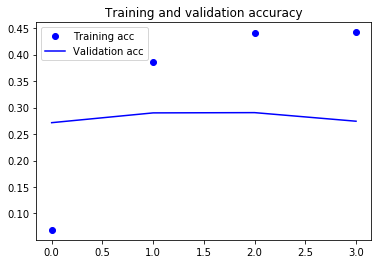

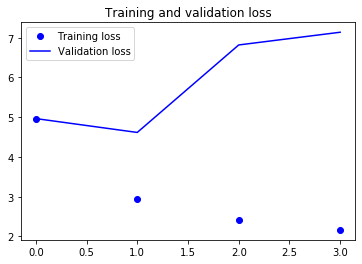

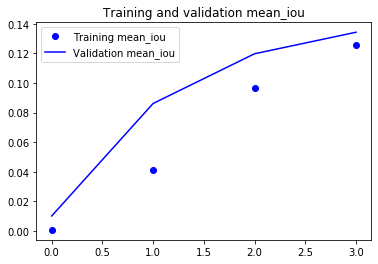

In [22]:
import matplotlib.pyplot as plt

acc = his.history['acc']
val_acc = his.history['val_acc']
loss = his.history['loss']
val_loss = his.history['val_loss']

mean_iou = his.history['mean_iou']
val_mean_iou = his.history['val_mean_iou']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

#plt.savefig("M2 Training and validation accuracy.png")

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

#plt.savefig("M2 Training and validation loss.png")
plt.show()

plt.plot(epochs, mean_iou, 'bo', label='Training mean_iou')
plt.plot(epochs, val_mean_iou, 'b', label='Validation mean_iou')
plt.title('Training and validation mean_iou')
plt.legend()

#plt.savefig("M2 Training and validation mean_iou.png")
plt.show()